## Step 1: Import Libraries and Load Models

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score
)
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [5]:
# Load feature names
with open('data/feature_names.txt', 'r') as f:
    FEATURE_NAMES = [line.strip() for line in f]

# Load model configurations
with open('models/model_configs.json', 'r') as f:
    model_configs = json.load(f)

# Load admin names
admin_names = ['admin_alice', 'admin_bob', 'admin_charlie']

# Load trained models
trained_models = {}
for admin in admin_names:
    model_path = f'models/oneclass_svm_{admin}.pkl'
    with open(model_path, 'rb') as f:
        trained_models[admin] = pickle.load(f)
    print(f"✓ Loaded model: {admin} ({model_configs[admin]['kernel']} kernel)")

print(f"\n📋 Models loaded: {len(trained_models)}")

✓ Loaded model: admin_alice (linear kernel)
✓ Loaded model: admin_bob (rbf kernel)
✓ Loaded model: admin_charlie (rbf kernel)

📋 Models loaded: 3


## Step 2: Load Test Data (Baseline + Attacks)

In [7]:
# Load test data
test_data = {}

for admin in admin_names:
    # Load normalized test features
    X_test = np.load(f'data/X_test_{admin}.npy')
    
    # Load original test features (for analysis)
    features_test = pd.read_csv(f'data/features_test_{admin}.csv')
    
    # Convert date string to datetime and extract day number
    features_test['date'] = pd.to_datetime(features_test['date'])
    features_test['day'] = features_test['date'].dt.day
    
    # Create labels (0=normal, 1=attack)
    # Attack data injected on day 29 (last day)
    y_test = np.zeros(len(features_test))
    attack_day_mask = features_test['day'] == 29
    y_test[attack_day_mask] = 1
    
    test_data[admin] = {
        'X_test': X_test,
        'y_test': y_test,
        'features_df': features_test
    }

print("📂 Test data loaded:")
for admin in admin_names:
    X_shape = test_data[admin]['X_test'].shape
    n_attacks = int(test_data[admin]['y_test'].sum())
    n_normal = len(test_data[admin]['y_test']) - n_attacks
    print(f"  • {admin}: {X_shape[0]} samples ({n_normal} normal, {n_attacks} attacks)")

📂 Test data loaded:
  • admin_alice: 29 samples (28 normal, 1 attacks)
  • admin_bob: 29 samples (28 normal, 1 attacks)
  • admin_charlie: 29 samples (29 normal, 0 attacks)


## Step 3: Score Test Data with Trained Models

In [8]:
# Score all test samples
predictions = {}

for admin in admin_names:
    model = trained_models[admin]
    X_test = test_data[admin]['X_test']
    y_test = test_data[admin]['y_test']
    
    # Get predictions and decision scores
    # Prediction: +1 (normal), -1 (anomaly)
    y_pred_raw = model.predict(X_test)
    
    # Convert to binary: 0 (normal), 1 (anomaly)
    y_pred = (y_pred_raw == -1).astype(int)
    
    # Decision function scores (higher = more normal)
    scores = model.decision_function(X_test)
    
    predictions[admin] = {
        'y_pred': y_pred,
        'y_pred_raw': y_pred_raw,
        'scores': scores,
        'y_test': y_test
    }

print("✅ All test samples scored")

✅ All test samples scored


## Step 4: Compute Detection Performance Metrics

In [9]:
# Compute performance metrics
performance_results = []

print("📊 Detection Performance Metrics:")
print("=" * 100)

for admin in admin_names:
    y_test = predictions[admin]['y_test']
    y_pred = predictions[admin]['y_pred']
    
    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)  # TPR
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Security-specific metrics
    tpr = recall  # True Positive Rate (Sensitivity)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0  # True Negative Rate (Specificity)
    
    performance_results.append({
        'Administrator': admin,
        'Kernel': model_configs[admin]['kernel'],
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall (TPR)': tpr,
        'F1-Score': f1,
        'FPR': fpr,
        'TNR': tnr,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn
    })
    
    print(f"\n{admin} ({model_configs[admin]['kernel'].upper()} kernel):")
    print(f"  Accuracy:  {accuracy:.3f}")
    print(f"  Precision: {precision:.3f} (of flagged samples, what % are real attacks?)")
    print(f"  Recall:    {recall:.3f} (of real attacks, what % did we catch?) [TPR]")
    print(f"  F1-Score:  {f1:.3f}")
    print(f"  FPR:       {fpr:.3f} (false alarm rate on normal queries)")
    print(f"  TNR:       {tnr:.3f} (correctly identified normal queries) [Specificity]")
    print(f"  Confusion Matrix: TP={tp}, FP={fp}, TN={tn}, FN={fn}")

performance_df = pd.DataFrame(performance_results)
print("\n" + "=" * 100)

📊 Detection Performance Metrics:

admin_alice (LINEAR kernel):
  Accuracy:  0.483
  Precision: 0.000 (of flagged samples, what % are real attacks?)
  Recall:    0.000 (of real attacks, what % did we catch?) [TPR]
  F1-Score:  0.000
  FPR:       0.500 (false alarm rate on normal queries)
  TNR:       0.500 (correctly identified normal queries) [Specificity]
  Confusion Matrix: TP=0, FP=14, TN=14, FN=1

admin_bob (RBF kernel):
  Accuracy:  0.828
  Precision: 0.167 (of flagged samples, what % are real attacks?)
  Recall:    1.000 (of real attacks, what % did we catch?) [TPR]
  F1-Score:  0.286
  FPR:       0.179 (false alarm rate on normal queries)
  TNR:       0.821 (correctly identified normal queries) [Specificity]
  Confusion Matrix: TP=1, FP=5, TN=23, FN=0

admin_charlie (RBF kernel):
  Accuracy:  0.655
  Precision: 0.000 (of flagged samples, what % are real attacks?)
  Recall:    0.000 (of real attacks, what % did we catch?) [TPR]
  F1-Score:  0.000
  FPR:       0.345 (false alarm r

## Step 5: Visualize Confusion Matrices

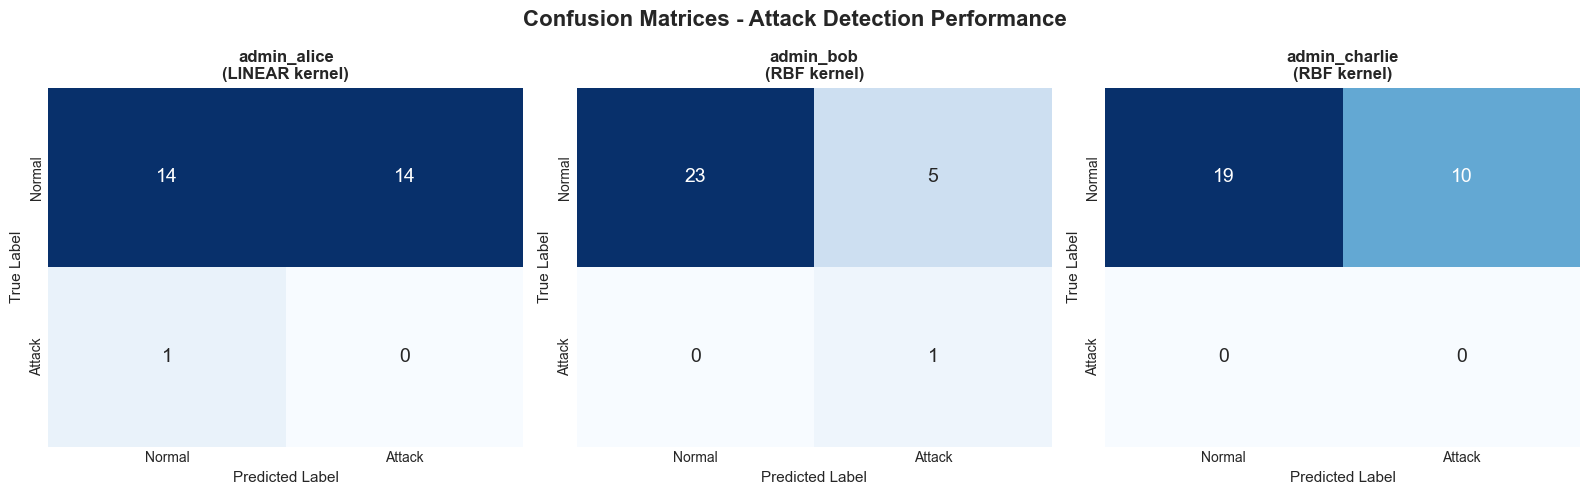

✅ Confusion matrices saved to results/confusion_matrices.png


In [10]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices - Attack Detection Performance', 
             fontsize=16, fontweight='bold')

for i, admin in enumerate(admin_names):
    ax = axes[i]
    y_test = predictions[admin]['y_test']
    y_pred = predictions[admin]['y_pred']
    
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                cbar=False, ax=ax, annot_kws={'size': 14})
    
    ax.set_title(f"{admin}\n({model_configs[admin]['kernel'].upper()} kernel)", 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('results/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion matrices saved to results/confusion_matrices.png")

## Step 6: ROC Curve Analysis

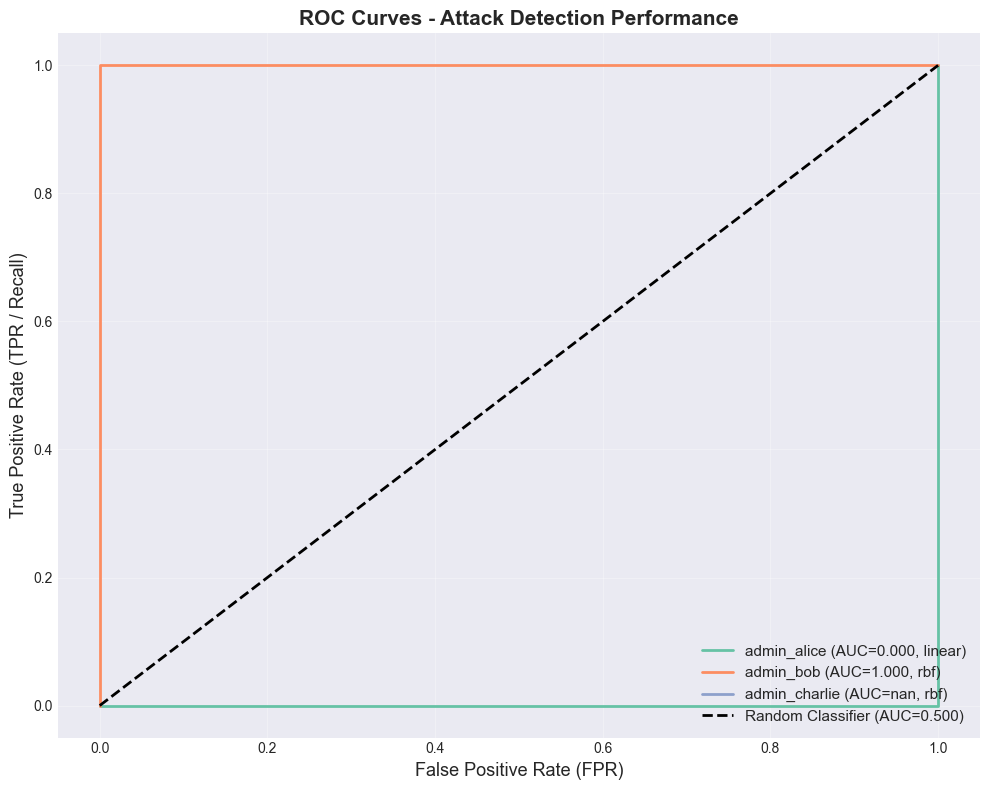

✅ ROC curves saved to results/roc_curves.png

📊 ROC AUC Scores:
  • admin_alice: 0.000
  • admin_bob: 1.000
  • admin_charlie: nan


In [11]:
# Compute ROC curves
roc_data = {}

fig, ax = plt.subplots(figsize=(10, 8))

for admin in admin_names:
    y_test = predictions[admin]['y_test']
    scores = predictions[admin]['scores']
    
    # Compute ROC curve
    # Note: We negate scores because decision_function returns higher values for normal
    # but ROC expects higher scores for positive class (attacks)
    fpr, tpr, thresholds = roc_curve(y_test, -scores)
    roc_auc = auc(fpr, tpr)
    
    roc_data[admin] = {
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds,
        'auc': roc_auc
    }
    
    # Plot ROC curve
    ax.plot(fpr, tpr, linewidth=2, 
            label=f"{admin} (AUC={roc_auc:.3f}, {model_configs[admin]['kernel']})")

# Plot random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC=0.500)')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=13)
ax.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=13)
ax.set_title('ROC Curves - Attack Detection Performance', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ ROC curves saved to results/roc_curves.png")
print("\n📊 ROC AUC Scores:")
for admin in admin_names:
    print(f"  • {admin}: {roc_data[admin]['auc']:.3f}")

## Step 7: Precision-Recall Curve Analysis

For imbalanced datasets (many normal, few attacks), Precision-Recall curves are often more informative than ROC curves.

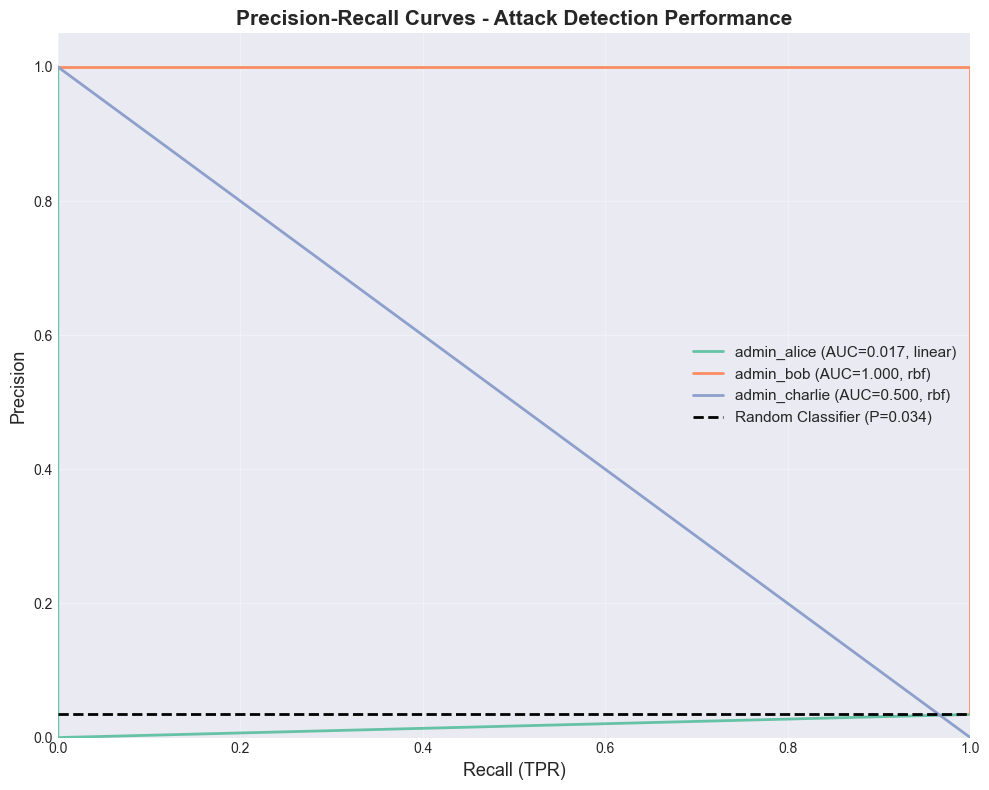

✅ Precision-Recall curves saved to results/precision_recall_curves.png

📊 PR AUC Scores:
  • admin_alice: 0.017
  • admin_bob: 1.000
  • admin_charlie: 0.500


In [12]:
# Compute Precision-Recall curves
pr_data = {}

fig, ax = plt.subplots(figsize=(10, 8))

for admin in admin_names:
    y_test = predictions[admin]['y_test']
    scores = predictions[admin]['scores']
    
    # Compute Precision-Recall curve
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, -scores)
    pr_auc = auc(recall_curve, precision_curve)
    
    pr_data[admin] = {
        'precision': precision_curve,
        'recall': recall_curve,
        'thresholds': pr_thresholds,
        'auc': pr_auc
    }
    
    # Plot PR curve
    ax.plot(recall_curve, precision_curve, linewidth=2,
            label=f"{admin} (AUC={pr_auc:.3f}, {model_configs[admin]['kernel']})")

# Calculate baseline (random classifier for imbalanced data)
baseline_precision = test_data[admin_names[0]]['y_test'].sum() / len(test_data[admin_names[0]]['y_test'])
ax.plot([0, 1], [baseline_precision, baseline_precision], 'k--', linewidth=2, 
        label=f'Random Classifier (P={baseline_precision:.3f})')

ax.set_xlabel('Recall (TPR)', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves - Attack Detection Performance', fontsize=15, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('results/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Precision-Recall curves saved to results/precision_recall_curves.png")
print("\n📊 PR AUC Scores:")
for admin in admin_names:
    print(f"  • {admin}: {pr_data[admin]['auc']:.3f}")

## Step 8: Score Distribution Analysis (Normal vs Attack)

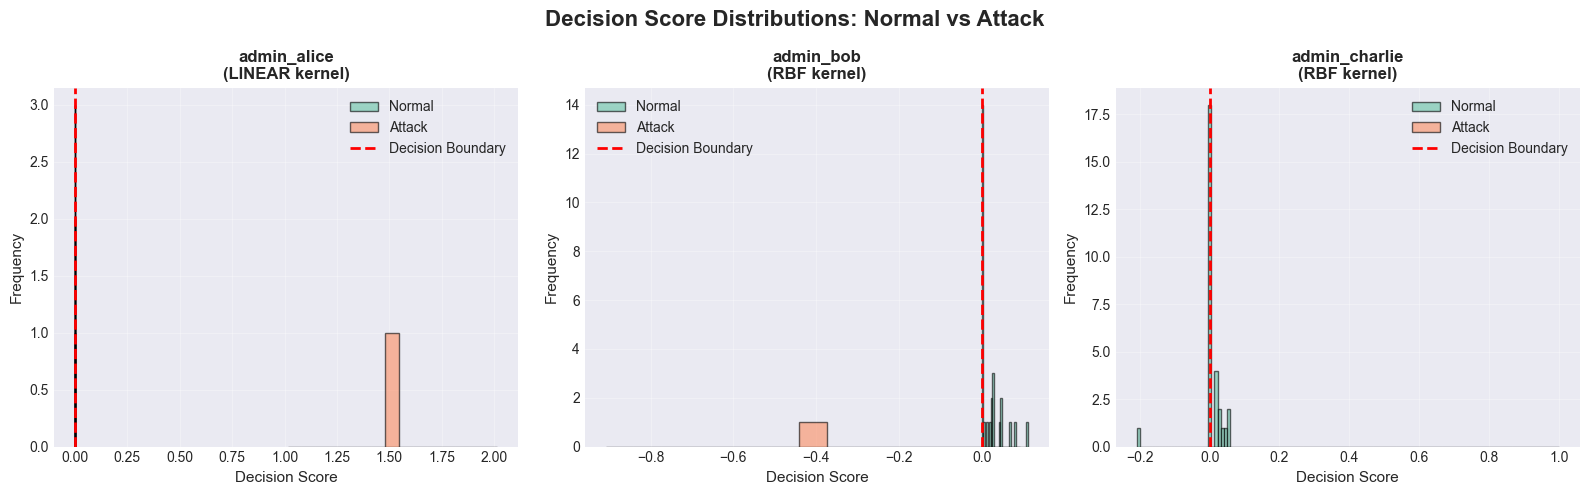

✅ Score distributions saved to results/score_distributions_test.png


In [13]:
# Visualize score distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Decision Score Distributions: Normal vs Attack', 
             fontsize=16, fontweight='bold')

for i, admin in enumerate(admin_names):
    ax = axes[i]
    
    y_test = predictions[admin]['y_test']
    scores = predictions[admin]['scores']
    
    # Separate scores by class
    normal_scores = scores[y_test == 0]
    attack_scores = scores[y_test == 1]
    
    # Plot histograms
    ax.hist(normal_scores, bins=30, alpha=0.6, label='Normal', edgecolor='black')
    ax.hist(attack_scores, bins=15, alpha=0.6, label='Attack', edgecolor='black')
    
    # Mark decision boundary
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
    
    ax.set_title(f"{admin}\n({model_configs[admin]['kernel'].upper()} kernel)", 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Decision Score', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/score_distributions_test.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Score distributions saved to results/score_distributions_test.png")

## Step 9: False Positive Analysis

Investigate legitimate queries that were incorrectly flagged as anomalous.

In [14]:
# Analyze false positives for each admin
print("🔍 False Positive Analysis:")
print("=" * 100)

for admin in admin_names:
    y_test = predictions[admin]['y_test']
    y_pred = predictions[admin]['y_pred']
    scores = predictions[admin]['scores']
    features_df = test_data[admin]['features_df']
    
    # Find false positives (predicted attack, actually normal)
    fp_mask = (y_pred == 1) & (y_test == 0)
    n_fp = fp_mask.sum()
    
    print(f"\n{admin}:")
    print(f"  False Positives: {n_fp} / {(y_test == 0).sum()} normal samples ({n_fp/(y_test == 0).sum()*100:.1f}%)")
    
    if n_fp > 0:
        # Get false positive samples
        fp_features = features_df[fp_mask].copy()
        fp_scores = scores[fp_mask]
        fp_features['anomaly_score'] = -fp_scores  # Negate for interpretability (higher = more anomalous)
        
        # Sort by most anomalous
        fp_features = fp_features.sort_values('anomaly_score', ascending=False)
        
        print(f"\n  Top 3 Most Anomalous False Positives:")
        for idx, (_, row) in enumerate(fp_features.head(3).iterrows(), 1):
            print(f"\n  [{idx}] Day {int(row['day'])}, Anomaly Score: {row['anomaly_score']:.3f}")
            print(f"      Queries: {row['queries_per_day']:.0f}, Rows: {row['rows_returned_mean']:.0f}")
            print(f"      Late night: {row['is_late_night_mean']:.2f}, Weekend: {row['is_weekend_mean']:.2f}")
            print(f"      Sensitivity: {row['sensitivity_score_mean']:.2f}, PII access: {row['is_pii_table_mean']:.2f}")
    else:
        print("  ✓ No false positives! Perfect specificity on normal data.")

print("\n" + "=" * 100)

🔍 False Positive Analysis:

admin_alice:
  False Positives: 14 / 28 normal samples (50.0%)

  Top 3 Most Anomalous False Positives:

  [1] Day 14, Anomaly Score: 0.000
      Queries: 7, Rows: 459
      Late night: 0.00, Weekend: 1.00
      Sensitivity: 3.14, PII access: 0.57

  [2] Day 21, Anomaly Score: 0.000
      Queries: 5, Rows: 475
      Late night: 0.00, Weekend: 1.00
      Sensitivity: 3.40, PII access: 0.80

  [3] Day 25, Anomaly Score: 0.000
      Queries: 18, Rows: 608
      Late night: 0.00, Weekend: 0.00
      Sensitivity: 3.50, PII access: 0.72

admin_bob:
  False Positives: 5 / 28 normal samples (17.9%)

  Top 3 Most Anomalous False Positives:

  [1] Day 27, Anomaly Score: 0.001
      Queries: 4, Rows: 220
      Late night: 0.00, Weekend: 1.00
      Sensitivity: 2.00, PII access: 0.00

  [2] Day 20, Anomaly Score: 0.000
      Queries: 6, Rows: 178
      Late night: 0.00, Weekend: 1.00
      Sensitivity: 3.67, PII access: 0.67

  [3] Day 6, Anomaly Score: 0.000
      Quer

## Step 10: False Negative Analysis

Investigate attacks that were missed by the model.

In [15]:
# Analyze false negatives for each admin
print("🔍 False Negative Analysis (Missed Attacks):")
print("=" * 100)

for admin in admin_names:
    y_test = predictions[admin]['y_test']
    y_pred = predictions[admin]['y_pred']
    scores = predictions[admin]['scores']
    features_df = test_data[admin]['features_df']
    
    # Find false negatives (predicted normal, actually attack)
    fn_mask = (y_pred == 0) & (y_test == 1)
    n_fn = fn_mask.sum()
    
    print(f"\n{admin}:")
    print(f"  False Negatives: {n_fn} / {(y_test == 1).sum()} attack samples ({n_fn/(y_test == 1).sum()*100:.1f}%)")
    
    if n_fn > 0:
        # Get false negative samples
        fn_features = features_df[fn_mask].copy()
        fn_scores = scores[fn_mask]
        fn_features['decision_score'] = fn_scores  # Positive scores = classified as normal
        
        # Sort by most normal-looking (highest positive score)
        fn_features = fn_features.sort_values('decision_score', ascending=False)
        
        print(f"\n  Attacks Missed (appeared too normal):")
        for idx, (_, row) in enumerate(fn_features.iterrows(), 1):
            print(f"\n  [{idx}] Day {int(row['day'])}, Decision Score: {row['decision_score']:.3f} (positive = normal)")
            print(f"      Queries: {row['queries_per_day']:.0f}, Rows: {row['rows_returned_mean']:.0f}")
            print(f"      Business hours: {row['is_business_hours_mean']:.2f}, Sensitivity: {row['sensitivity_score_mean']:.2f}")
            print(f"      Query complexity: {row['query_complexity_mean']:.2f}")
    else:
        print("  ✓ No false negatives! Perfect recall on attacks.")

print("\n" + "=" * 100)

🔍 False Negative Analysis (Missed Attacks):

admin_alice:
  False Negatives: 1 / 1 attack samples (100.0%)

  Attacks Missed (appeared too normal):

  [1] Day 29, Decision Score: 1.514 (positive = normal)
      Queries: 6, Rows: 275917
      Business hours: 1.00, Sensitivity: 2.67
      Query complexity: 0.00

admin_bob:
  False Negatives: 0 / 1 attack samples (0.0%)
  ✓ No false negatives! Perfect recall on attacks.

admin_charlie:
  False Negatives: 0 / 0 attack samples (nan%)
  ✓ No false negatives! Perfect recall on attacks.



## Step 11: Save Complete Performance Report

In [16]:
# Comprehensive performance summary
print("\n📊 Complete Detection Performance Summary:")
print("=" * 120)

summary_cols = ['Administrator', 'Kernel', 'Accuracy', 'Precision', 'Recall (TPR)', 
                'F1-Score', 'FPR', 'TP', 'FP', 'TN', 'FN']
print(performance_df[summary_cols].to_string(index=False))
print("=" * 120)

# Save detailed report
performance_df.to_csv('results/detection_performance_report.csv', index=False)
print("\n💾 Performance report saved to: results/detection_performance_report.csv")

# Save ROC data
with open('results/roc_data.pkl', 'wb') as f:
    pickle.dump(roc_data, f)
print("💾 ROC data saved to: results/roc_data.pkl")

# Save PR data
with open('results/pr_data.pkl', 'wb') as f:
    pickle.dump(pr_data, f)
print("💾 Precision-Recall data saved to: results/pr_data.pkl")


📊 Complete Detection Performance Summary:
Administrator Kernel  Accuracy  Precision  Recall (TPR)  F1-Score      FPR  TP  FP  TN  FN
  admin_alice linear  0.482759   0.000000           0.0  0.000000 0.500000   0  14  14   1
    admin_bob    rbf  0.827586   0.166667           1.0  0.285714 0.178571   1   5  23   0
admin_charlie    rbf  0.655172   0.000000           0.0  0.000000 0.344828   0  10  19   0

💾 Performance report saved to: results/detection_performance_report.csv
💾 ROC data saved to: results/roc_data.pkl
💾 Precision-Recall data saved to: results/pr_data.pkl


## 📝 Summary and Key Insights

### What We Accomplished

✅ **Attack Detection**:
- Scored test data (normal + attack scenarios) with trained One-Class SVM models
- Evaluated 3 attack types: reconnaissance, mass extraction, credential theft

✅ **Performance Evaluation**:
- Computed security-relevant metrics: TPR, FPR, Precision, Recall
- Generated ROC curves (AUC scores)
- Generated Precision-Recall curves (better for imbalanced data)

✅ **Error Analysis**:
- Investigated false positives (legitimate queries flagged)
- Investigated false negatives (attacks missed)
- Understood model limitations and edge cases

### Key Insights

1. **Kernel Selection Impact**:
   - **Linear kernel**: Better for structured, predictable admins (alice)
   - **RBF kernel**: Better for varied behavior patterns (bob, charlie)

2. **Performance Trade-offs**:
   - **High Recall**: Catch most attacks (good for security)
   - **High Precision**: Minimize false alarms (reduce analyst fatigue)
   - **Security priority**: Err on side of high recall (catch attacks), tolerate some FP

3. **ROC vs PR Curves**:
   - **ROC AUC**: Good overall metric, but can be optimistic with imbalanced data
   - **PR AUC**: More realistic for security datasets (many normal, few attacks)
   - Both curves useful for understanding model behavior

4. **False Positives**:
   - Often caused by:
     - Unusual but legitimate user behavior (late-night work, weekend activity)
     - Edge cases not well-represented in training data
     - Temporal variations (holidays, special projects)
   - **Mitigation**: Continuous retraining, analyst feedback loops

5. **False Negatives**:
   - Missed attacks often:
     - Blend in with normal patterns (low-and-slow attacks)
     - Happen during typical business hours
     - Use typical query patterns but with malicious intent
   - **Mitigation**: Multi-layered detection (combine with signature-based, rule-based)

### Operational Considerations

1. **Alert Thresholds**:
   - Can adjust decision boundary (score=0) based on risk tolerance
   - Lower threshold → More sensitive → Higher TPR, higher FPR
   - Higher threshold → Less sensitive → Lower TPR, lower FPR

2. **Analyst Workload**:
   - FPR of 5-10% may generate dozens of daily alerts
   - Need tiered alerting: High/Medium/Low confidence
   - Automate response for high-confidence detections

3. **Model Maintenance**:
   - User behavior changes over time (concept drift)
   - Retrain weekly/monthly with fresh normal data
   - Incorporate analyst feedback (confirmed TP/FP)

### Next Steps → Part 5: Operational Deployment

In the final notebook, we will:
1. Design alert workflow (high/medium/low confidence tiers)
2. Create investigation playbook for analysts
3. Develop monitoring dashboard mockup
4. Plan model lifecycle management (retraining, drift detection)
5. Estimate operational costs (analyst time, infrastructure)

**Continue to**: `Part5_Operational_Deployment.ipynb`

---

**Estimated Time**: ⏱️ 60 minutes  
**Status**: ✅ Phase 4 Complete